In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
zip_path = "/content/archive (13).zip"
extract_path = "/content/cats_dogs"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
train_dir = None
val_dir = None

for root, dirs, files in os.walk(extract_path):

    if os.path.basename(root).lower() == "train":
        if os.path.isdir(os.path.join(root, "cat")) and os.path.isdir(os.path.join(root, "dog")):
            train_dir = root

    if os.path.basename(root).lower() in ["val", "validation"]:
        if os.path.isdir(os.path.join(root, "cat")) and os.path.isdir(os.path.join(root, "dog")):
            val_dir = root

print("Train folder:", train_dir)
print("Validation folder:", val_dir)

Train folder: /content/cats_dogs/train
Validation folder: /content/cats_dogs/val


In [ ]:
if train_dir is None:
    raise FileNotFoundError("Training folder was not found.")

if val_dir is None:
    raise FileNotFoundError("Validation folder was not found.")

print("Train folder found successfully!")
print("Validation folder found successfully!")

Train folder found successfully!
Validation folder found successfully!


In [ ]:
print("Training folders:")
print(os.listdir(train_dir))

print("\nValidation folders:")
print(os.listdir(val_dir))

Training folders:
['cat', 'classname.txt', 'dog']

Validation folders:
['cat', 'classname.txt', 'dog']


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # ONE data augmentation technique
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))

Classes: ['cat', 'dog']
Class to index: {'cat': 0, 'dog': 1}
Number of training images: 275
Number of validation images: 70


In [ ]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 18
Validation batches: 5


In [ ]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1])


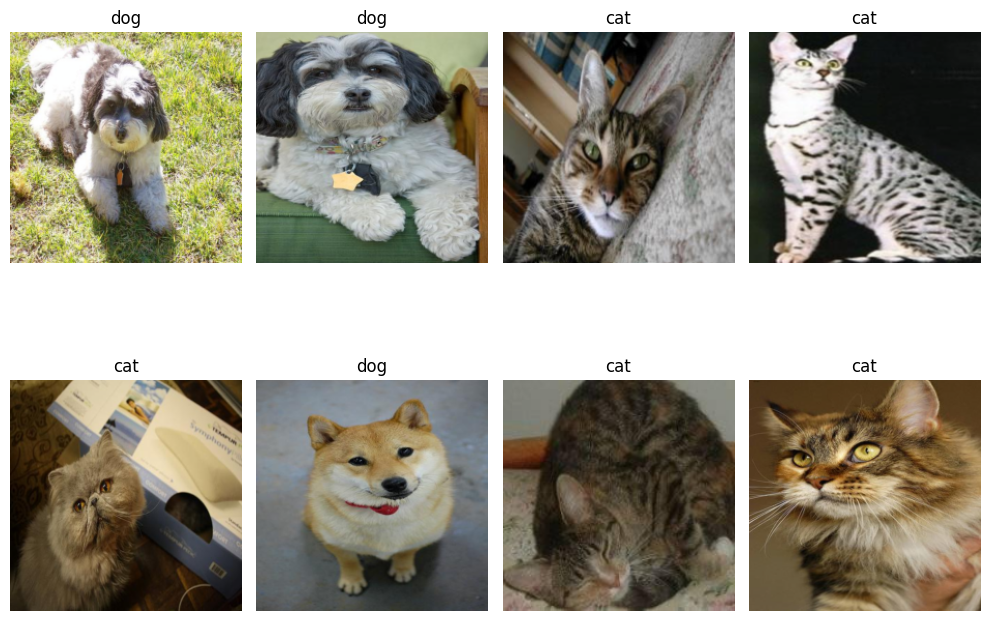

In [ ]:
classes = train_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 8))

for i in range(min(8, len(images))):

    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [ ]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Change final layer for 2 classes:
# 0 = Cat
# 1 = Dog

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

print("ResNet18 model created successfully!")

ResNet18 model created successfully!


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
num_epochs = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(num_epochs):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update model weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

        # Find predicted class
        _, predicted = torch.max(outputs, 1)

        # Count images
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()


    # Calculate training loss
    train_loss = running_loss / len(train_loader)

    # Calculate training accuracy
    train_accuracy = 100 * correct / total

    # Store results
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Prediction
            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            # Predicted class
            _, predicted = torch.max(outputs, 1)

            # Count images
            val_total += labels.size(0)

            # Count correct predictions
            val_correct += (predicted == labels).sum().item()


    # Calculate validation loss
    val_loss = val_running_loss / len(val_loader)

    # Calculate validation accuracy
    val_accuracy = 100 * val_correct / val_total

    # Store results
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Accuracy: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.3508 | Train Accuracy: 86.18% | Val Loss: 5.0497 | Val Accuracy: 67.14%
Epoch [2/10] | Train Loss: 0.2252 | Train Accuracy: 92.73% | Val Loss: 0.3415 | Val Accuracy: 90.00%
Epoch [3/10] | Train Loss: 0.2684 | Train Accuracy: 91.27% | Val Loss: 0.9541 | Val Accuracy: 87.14%
Epoch [4/10] | Train Loss: 0.2765 | Train Accuracy: 88.36% | Val Loss: 0.2457 | Val Accuracy: 82.86%
Epoch [5/10] | Train Loss: 0.1271 | Train Accuracy: 94.18% | Val Loss: 0.3222 | Val Accuracy: 87.14%
Epoch [6/10] | Train Loss: 0.1410 | Train Accuracy: 95.27% | Val Loss: 0.2479 | Val Accuracy: 90.00%
Epoch [7/10] | Train Loss: 0.0765 | Train Accuracy: 97.45% | Val Loss: 0.2475 | Val Accuracy: 94.29%
Epoch [8/10] | Train Loss: 0.1424 | Train Accuracy: 99.64% | Val Loss: 0.2794 | Val Accuracy: 94.29%
Epoch [9/10] | Train Loss: 0.2059 | Train Accuracy: 94.18% | Val Loss: 0.9452 | Val Accuracy: 80.00%
Epoch [10/10] | Train Loss: 0.1930 | Train Accuracy: 93.82% | Val Loss: 2.1132 | Val Accura

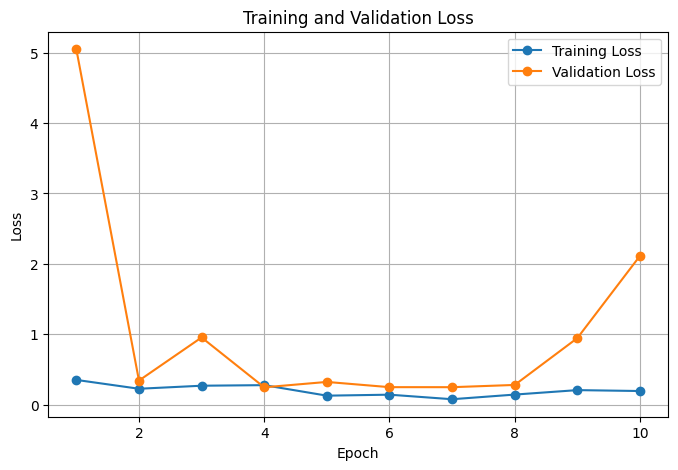

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

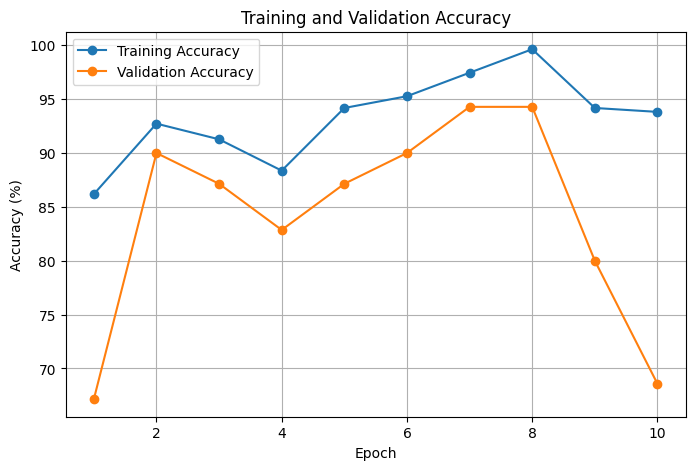

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, num_epochs + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predicted.cpu().numpy()
        )

print("Evaluation completed!")

Evaluation completed!


In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 68.57%


In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 68.57%


In [ ]:
recall = recall_score(
    all_labels,
    all_predictions,
    average="binary",
    zero_division=0
)

print(f"Recall: {recall:.4f}")

Recall: 0.9783


In [ ]:
f1 = f1_score(
    all_labels,
    all_predictions,
    average="binary",
    zero_division=0
)

print(f"F1-score: {f1:.4f}")

F1-score: 0.8036


In [ ]:
print("\n========== FINAL RESULTS ==========")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


========== FINAL RESULTS ==========
Accuracy  : 68.57%
Precision : 0.6818
Recall    : 0.9783
F1-score  : 0.8036


In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 3 21]
 [ 1 45]]


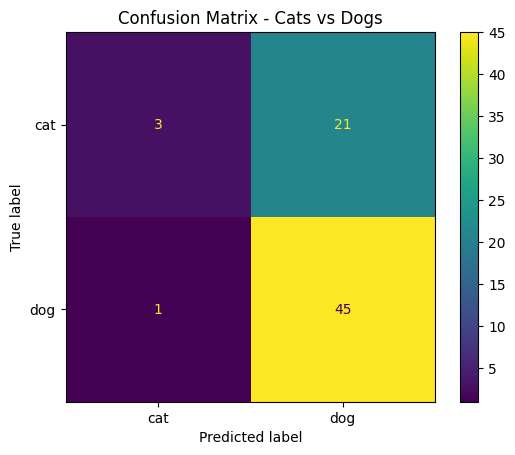

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("Confusion Matrix - Cats vs Dogs")
plt.show()

In [ ]:
print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        zero_division=0
    )
)

In [ ]:
from PIL import Image

# Select first validation image
image_path, actual_label = val_dataset.samples[0]

print("Image path:", image_path)
print("Actual class:", classes[actual_label])

In [ ]:
image = Image.open(image_path).convert("RGB")

input_image = val_transform(image)

input_image = input_image.unsqueeze(0)

input_image = input_image.to(device)

In [ ]:
model.eval()

with torch.no_grad():

    output = model(input_image)

    _, predicted = torch.max(output, 1)

predicted_class = classes[predicted.item()]

print("Actual class:", classes[actual_label])
print("Predicted class:", predicted_class)

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Actual: {classes[actual_label]} | "
    f"Predicted: {predicted_class}"
)

plt.axis("off")

plt.show()